# Inner Product (Dot Product): Measuring Alignment

The **inner product** (or dot product) is one of the most important operations in linear algebra. It takes two vectors and returns a **scalar**:

$$\mathbf{x}^T \mathbf{y} = \sum_{i=1}^n x_i y_i = x_1 y_1 + x_2 y_2 + \cdots + x_n y_n$$

### Geometric Interpretation

The inner product has a beautiful geometric meaning:

$$\mathbf{x}^T \mathbf{y} = \|\mathbf{x}\| \|\mathbf{y}\| \cos(\theta)$$

Where $\theta$ is the angle between the vectors. This tells us:
- **Positive**: vectors point in similar directions ($\theta < 90°$)
- **Zero**: vectors are perpendicular/orthogonal ($\theta = 90°$)
- **Negative**: vectors point in opposite directions ($\theta > 90°$)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Arc
import matplotlib.patches as mpatches

np.random.seed(42)
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

---
## 1. Computing the Inner Product

The computation is simple: multiply corresponding elements and sum.

In [2]:
# Basic inner product computation
x = np.array([1, 2, 3])
y = np.array([4, 5, 6])

# Multiple ways to compute
inner1 = np.dot(x, y)      # Explicit function
inner2 = x @ y             # Matrix multiplication operator
inner3 = np.sum(x * y)     # Element-wise multiply then sum
inner4 = x[0]*y[0] + x[1]*y[1] + x[2]*y[2]  # Manual

print(f"x = {x}")
print(f"y = {y}")
print(f"\nx · y = {x[0]}×{y[0]} + {x[1]}×{y[1]} + {x[2]}×{y[2]}")
print(f"      = {x[0]*y[0]} + {x[1]*y[1]} + {x[2]*y[2]}")
print(f"      = {inner1}")
print(f"\nAll methods give same result: {inner1 == inner2 == inner3 == inner4}")

x = [1 2 3]
y = [4 5 6]

x · y = 1×4 + 2×5 + 3×6
      = 4 + 10 + 18
      = 32

All methods give same result: True


---
## 2. Geometric Meaning: Projection and Alignment

The inner product tells us **how much** one vector points in the direction of another.

Think of it as: *"If I walk along $\mathbf{x}$, how far do I travel in the direction of $\mathbf{y}$?"*

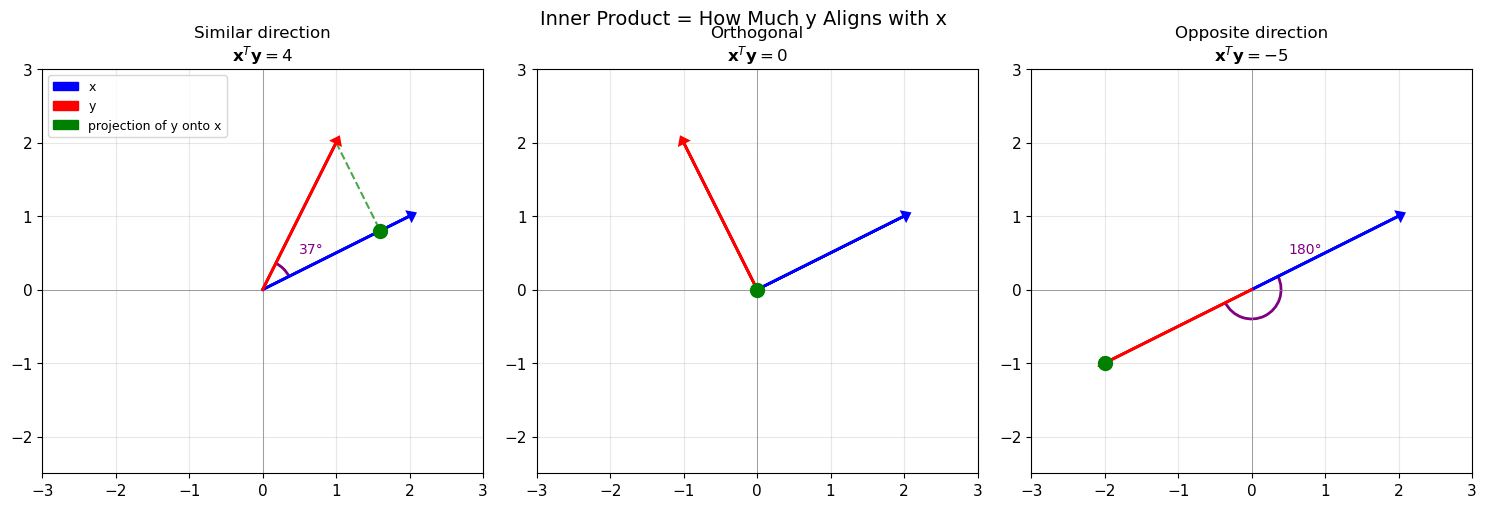

In [3]:
# Visualize inner product as projection
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

cases = [
    (np.array([2, 1]), np.array([1, 2]), "Similar direction"),
    (np.array([2, 1]), np.array([-1, 2]), "Orthogonal"),
    (np.array([2, 1]), np.array([-2, -1]), "Opposite direction")
]

for ax, (x, y, title) in zip(axes, cases):
    # Compute inner product
    inner = x @ y
    
    # Compute angle
    cos_theta = inner / (np.linalg.norm(x) * np.linalg.norm(y))
    theta = np.degrees(np.arccos(np.clip(cos_theta, -1, 1)))
    
    # Compute projection of y onto x
    proj_scalar = inner / (x @ x)  # How much of y in x direction
    proj_vec = proj_scalar * x     # The actual projection vector
    
    # Plot vectors
    ax.arrow(0, 0, x[0], x[1], head_width=0.12, head_length=0.08, 
             fc='blue', ec='blue', linewidth=2, zorder=3)
    ax.arrow(0, 0, y[0], y[1], head_width=0.12, head_length=0.08, 
             fc='red', ec='red', linewidth=2, zorder=3)
    
    # Show projection line (perpendicular from y to x)
    ax.plot([y[0], proj_vec[0]], [y[1], proj_vec[1]], 'g--', linewidth=1.5, alpha=0.7)
    ax.scatter([proj_vec[0]], [proj_vec[1]], color='green', s=100, zorder=5, marker='o')
    
    # Draw angle arc
    if abs(inner) > 0.01:  # Only draw if not perpendicular
        angle_x = np.degrees(np.arctan2(x[1], x[0]))
        angle_y = np.degrees(np.arctan2(y[1], y[0]))
        arc = Arc((0, 0), 0.8, 0.8, angle=0, theta1=min(angle_x, angle_y), 
                  theta2=max(angle_x, angle_y), color='purple', linewidth=2)
        ax.add_patch(arc)
        ax.text(0.5, 0.5, f'{theta:.0f}°', fontsize=10, color='purple')
    
    ax.set_xlim(-3, 3)
    ax.set_ylim(-2.5, 3)
    ax.axhline(y=0, color='gray', linewidth=0.5)
    ax.axvline(x=0, color='gray', linewidth=0.5)
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.3)
    ax.set_title(f"{title}\n$\\mathbf{{x}}^T \\mathbf{{y}} = {inner}$", fontsize=12)

# Legend
axes[0].legend([mpatches.Patch(color='blue'), mpatches.Patch(color='red'), mpatches.Patch(color='green')],
               ['x', 'y', 'projection of y onto x'], loc='upper left', fontsize=9)

plt.suptitle('Inner Product = How Much y Aligns with x', fontsize=14)
plt.tight_layout()
plt.show()

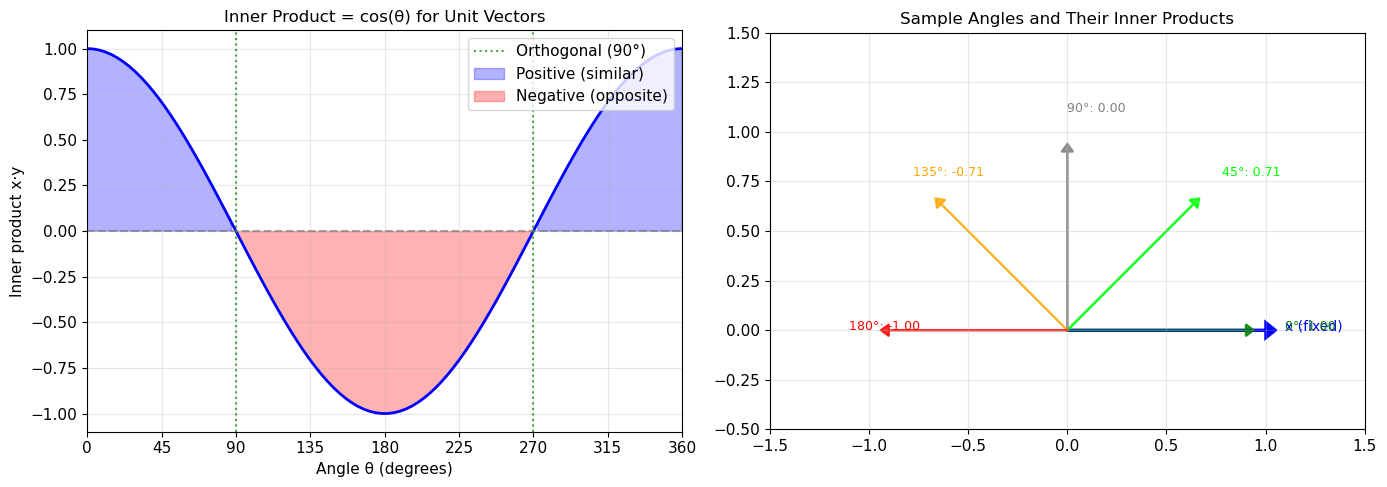

In [4]:
# Show how inner product varies with angle
angles = np.linspace(0, 2*np.pi, 100)
x = np.array([1, 0])  # Fixed vector along x-axis

inner_products = []
for theta in angles:
    y = np.array([np.cos(theta), np.sin(theta)])  # Unit vector at angle theta
    inner_products.append(x @ y)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot inner product vs angle
ax1 = axes[0]
ax1.plot(np.degrees(angles), inner_products, 'b-', linewidth=2)
ax1.axhline(y=0, color='gray', linestyle='--', alpha=0.7)
ax1.axvline(x=90, color='green', linestyle=':', alpha=0.7, label='Orthogonal (90°)')
ax1.axvline(x=270, color='green', linestyle=':', alpha=0.7)
ax1.fill_between(np.degrees(angles), inner_products, 0, 
                  where=np.array(inner_products) > 0, alpha=0.3, color='blue', label='Positive (similar)')
ax1.fill_between(np.degrees(angles), inner_products, 0, 
                  where=np.array(inner_products) < 0, alpha=0.3, color='red', label='Negative (opposite)')
ax1.set_xlabel('Angle θ (degrees)')
ax1.set_ylabel('Inner product x·y')
ax1.set_title('Inner Product = cos(θ) for Unit Vectors', fontsize=12)
ax1.legend(loc='upper right')
ax1.set_xlim(0, 360)
ax1.set_xticks([0, 45, 90, 135, 180, 225, 270, 315, 360])
ax1.grid(True, alpha=0.3)

# Show vectors at different angles
ax2 = axes[1]
ax2.arrow(0, 0, 1, 0, head_width=0.08, head_length=0.05, fc='blue', ec='blue', linewidth=2)
ax2.text(1.1, 0, 'x (fixed)', fontsize=10, color='blue')

sample_angles = [0, 45, 90, 135, 180]
colors = ['green', 'lime', 'gray', 'orange', 'red']
for theta, color in zip(sample_angles, colors):
    rad = np.radians(theta)
    y = np.array([np.cos(rad), np.sin(rad)])
    inner = x @ y
    ax2.arrow(0, 0, y[0]*0.9, y[1]*0.9, head_width=0.06, head_length=0.04, 
              fc=color, ec=color, linewidth=1.5, alpha=0.8)
    ax2.text(y[0]*1.1, y[1]*1.1, f'{theta}°: {inner:.2f}', fontsize=9, color=color)

ax2.set_xlim(-1.5, 1.5)
ax2.set_ylim(-0.5, 1.5)
ax2.set_aspect('equal')
ax2.grid(True, alpha=0.3)
ax2.set_title('Sample Angles and Their Inner Products', fontsize=12)

plt.tight_layout()
plt.show()

---
## Real-World Scenario: Movie Recommendations

**Scenario**: You're building a movie recommendation system. Each user and each movie is represented as a vector of features.

- **User vector**: preferences for [action, comedy, drama, sci-fi, romance]
- **Movie vector**: how much each genre applies [action, comedy, drama, sci-fi, romance]

The **inner product** between a user and a movie gives a **compatibility score**!

In [5]:
# Movie recommendation system
genres = ['Action', 'Comedy', 'Drama', 'Sci-Fi', 'Romance']

# User preference profiles (how much they like each genre, scale -1 to 1)
users = {
    'Alice':  np.array([0.9, -0.2, 0.3, 0.8, -0.5]),   # Loves action & sci-fi
    'Bob':    np.array([-0.3, 0.9, 0.4, 0.1, 0.7]),    # Loves comedy & romance
    'Carol':  np.array([0.2, 0.2, 0.9, 0.3, 0.6]),     # Loves drama & romance
}

# Movie genre profiles (how much each genre applies, scale 0 to 1)
movies = {
    'The Matrix':        np.array([0.9, 0.1, 0.3, 1.0, 0.1]),
    'Bridget Jones':     np.array([0.0, 0.8, 0.4, 0.0, 0.9]),
    'The Godfather':     np.array([0.6, 0.0, 1.0, 0.0, 0.2]),
    'Guardians Galaxy':  np.array([0.8, 0.7, 0.2, 0.8, 0.3]),
}

print("Genre Profiles")
print("=" * 60)
print(f"{'':18} {' '.join(f'{g:>8}' for g in genres)}")
print("-" * 60)
print("Users:")
for name, prefs in users.items():
    print(f"  {name:14} {' '.join(f'{p:>8.1f}' for p in prefs)}")
print("\nMovies:")
for name, profile in movies.items():
    print(f"  {name:14} {' '.join(f'{p:>8.1f}' for p in profile)}")

Genre Profiles
                     Action   Comedy    Drama   Sci-Fi  Romance
------------------------------------------------------------
Users:
  Alice               0.9     -0.2      0.3      0.8     -0.5
  Bob                -0.3      0.9      0.4      0.1      0.7
  Carol               0.2      0.2      0.9      0.3      0.6

Movies:
  The Matrix          0.9      0.1      0.3      1.0      0.1
  Bridget Jones       0.0      0.8      0.4      0.0      0.9
  The Godfather       0.6      0.0      1.0      0.0      0.2
  Guardians Galaxy      0.8      0.7      0.2      0.8      0.3


In [6]:
# Compute compatibility scores using inner product
print("\nCompatibility Scores (Inner Product)")
print("=" * 60)
print(f"{'User':<10} {'Movie':<18} {'Score':>8}  Interpretation")
print("-" * 60)

scores = {}
for user_name, user_prefs in users.items():
    scores[user_name] = {}
    for movie_name, movie_profile in movies.items():
        score = user_prefs @ movie_profile
        scores[user_name][movie_name] = score
        
        if score > 1.5:
            interp = "Great match!"
        elif score > 0.5:
            interp = "Good match"
        elif score > 0:
            interp = "Okay"
        else:
            interp = "Poor match"
            
        print(f"{user_name:<10} {movie_name:<18} {score:>8.2f}  {interp}")
    print()


Compatibility Scores (Inner Product)
User       Movie                 Score  Interpretation
------------------------------------------------------------
Alice      The Matrix             1.63  Great match!
Alice      Bridget Jones         -0.49  Poor match
Alice      The Godfather          0.74  Good match
Alice      Guardians Galaxy       1.13  Good match

Bob        The Matrix             0.11  Okay
Bob        Bridget Jones          1.51  Great match!
Bob        The Godfather          0.36  Okay
Bob        Guardians Galaxy       0.76  Good match

Carol      The Matrix             0.83  Good match
Carol      Bridget Jones          1.06  Good match
Carol      The Godfather          1.14  Good match
Carol      Guardians Galaxy       0.90  Good match



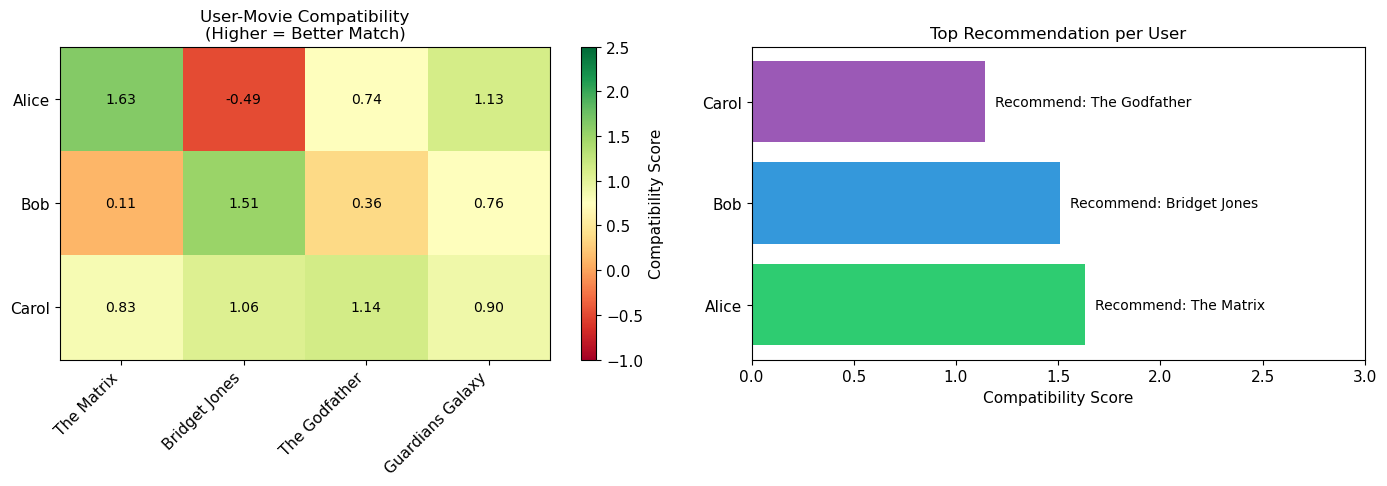


Recommendations:
  Alice: Watch 'The Matrix' (score: 1.63)
  Bob: Watch 'Bridget Jones' (score: 1.51)
  Carol: Watch 'The Godfather' (score: 1.14)


In [7]:
# Visualize as heatmap
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Score matrix
user_names = list(users.keys())
movie_names = list(movies.keys())
score_matrix = np.array([[scores[u][m] for m in movie_names] for u in user_names])

ax1 = axes[0]
im = ax1.imshow(score_matrix, cmap='RdYlGn', aspect='auto', vmin=-1, vmax=2.5)
ax1.set_xticks(range(len(movie_names)))
ax1.set_xticklabels(movie_names, rotation=45, ha='right')
ax1.set_yticks(range(len(user_names)))
ax1.set_yticklabels(user_names)
for i in range(len(user_names)):
    for j in range(len(movie_names)):
        ax1.text(j, i, f'{score_matrix[i,j]:.2f}', ha='center', va='center', fontsize=10)
plt.colorbar(im, ax=ax1, label='Compatibility Score')
ax1.set_title('User-Movie Compatibility\n(Higher = Better Match)', fontsize=12)

# Show best recommendation for each user
ax2 = axes[1]
best_movies = [movie_names[np.argmax(score_matrix[i])] for i in range(len(user_names))]
best_scores = [np.max(score_matrix[i]) for i in range(len(user_names))]
colors = ['#2ecc71', '#3498db', '#9b59b6']
bars = ax2.barh(user_names, best_scores, color=colors)
for i, (bar, movie) in enumerate(zip(bars, best_movies)):
    ax2.text(bar.get_width() + 0.05, bar.get_y() + bar.get_height()/2, 
             f'Recommend: {movie}', va='center', fontsize=10)
ax2.set_xlabel('Compatibility Score')
ax2.set_title('Top Recommendation per User', fontsize=12)
ax2.set_xlim(0, 3)

plt.tight_layout()
plt.show()

print("\nRecommendations:")
for user, movie, score in zip(user_names, best_movies, best_scores):
    print(f"  {user}: Watch '{movie}' (score: {score:.2f})")

---
## 3. The Projection Formula

The **projection** of $\mathbf{y}$ onto $\mathbf{x}$ is the "shadow" of $\mathbf{y}$ on the line defined by $\mathbf{x}$:

$$\text{proj}_{\mathbf{x}}(\mathbf{y}) = \frac{\mathbf{x}^T \mathbf{y}}{\mathbf{x}^T \mathbf{x}} \mathbf{x} = \frac{\mathbf{x}^T \mathbf{y}}{\|\mathbf{x}\|^2} \mathbf{x}$$

The scalar coefficient $\frac{\mathbf{x}^T \mathbf{y}}{\|\mathbf{x}\|^2}$ tells us "how many x's" fit in the projection.

In [8]:
# Detailed projection example
x = np.array([3, 1])
y = np.array([1, 2])

# Compute projection
inner_xy = x @ y
inner_xx = x @ x
proj_coef = inner_xy / inner_xx
proj = proj_coef * x

# The residual (perpendicular component)
residual = y - proj

print("Projection Calculation")
print("=" * 40)
print(f"x = {x}")
print(f"y = {y}")
print(f"\nx · y = {inner_xy}")
print(f"x · x = {inner_xx} = ||x||²")
print(f"\nProjection coefficient = {inner_xy}/{inner_xx} = {proj_coef:.3f}")
print(f"proj_x(y) = {proj_coef:.3f} × {x} = [{proj[0]:.3f}, {proj[1]:.3f}]")
print(f"\nResidual (y - proj) = {residual}")
print(f"\nVerify: residual ⊥ x? x · residual = {x @ residual:.6f} ≈ 0")

Projection Calculation
x = [3 1]
y = [1 2]

x · y = 5
x · x = 10 = ||x||²

Projection coefficient = 5/10 = 0.500
proj_x(y) = 0.500 × [3 1] = [1.500, 0.500]

Residual (y - proj) = [-0.5  1.5]

Verify: residual ⊥ x? x · residual = 0.000000 ≈ 0


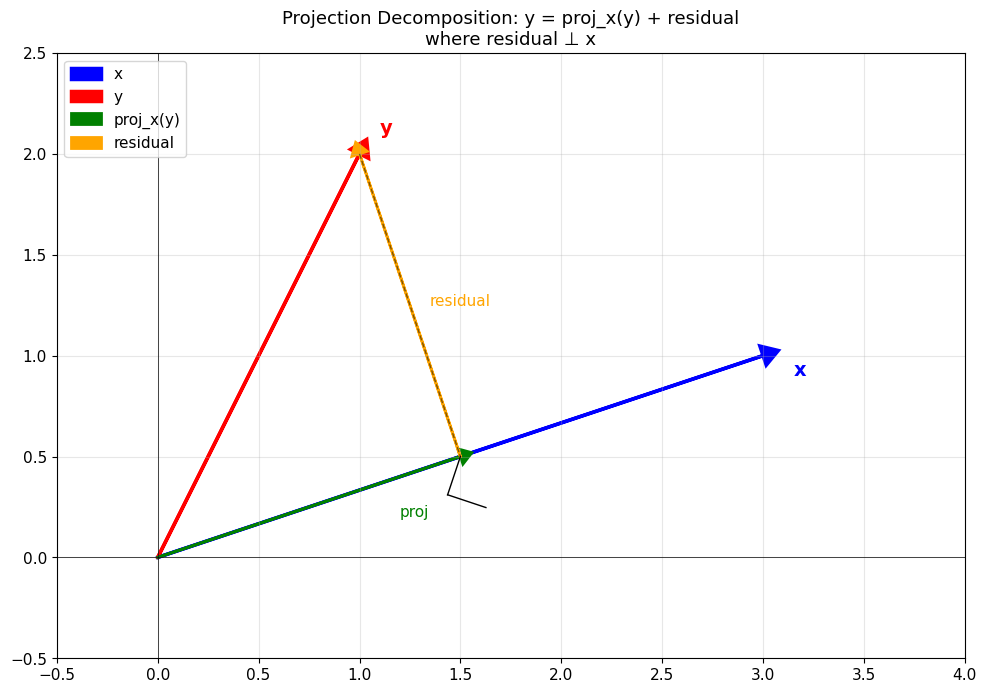

In [9]:
# Visualize the projection decomposition
fig, ax = plt.subplots(figsize=(10, 8))

# Original vectors
ax.arrow(0, 0, x[0], x[1], head_width=0.1, head_length=0.08, 
         fc='blue', ec='blue', linewidth=2.5, label='x')
ax.arrow(0, 0, y[0], y[1], head_width=0.1, head_length=0.08, 
         fc='red', ec='red', linewidth=2.5, label='y')

# Projection
ax.arrow(0, 0, proj[0], proj[1], head_width=0.08, head_length=0.06, 
         fc='green', ec='green', linewidth=2, label='proj_x(y)')

# Residual (from tip of projection to y)
ax.arrow(proj[0], proj[1], residual[0], residual[1], head_width=0.08, head_length=0.06, 
         fc='orange', ec='orange', linewidth=2, label='residual')

# Perpendicular mark
perp_size = 0.2
perp_x = np.array([residual[0], -residual[1]]) / np.linalg.norm(residual) * perp_size
perp_y = np.array([residual[1], residual[0]]) / np.linalg.norm(residual) * perp_size
ax.plot([proj[0], proj[0] + perp_x[0]], [proj[1], proj[1] + perp_x[1]], 'k-', linewidth=1)
ax.plot([proj[0] + perp_x[0], proj[0] + perp_x[0] + perp_y[0]], 
        [proj[1] + perp_x[1], proj[1] + perp_x[1] + perp_y[1]], 'k-', linewidth=1)

# Dashed line showing the decomposition
ax.plot([y[0], proj[0]], [y[1], proj[1]], 'k--', alpha=0.5, linewidth=1)

# Labels
ax.text(x[0] + 0.15, x[1] - 0.1, 'x', fontsize=14, color='blue', fontweight='bold')
ax.text(y[0] + 0.1, y[1] + 0.1, 'y', fontsize=14, color='red', fontweight='bold')
ax.text(proj[0] - 0.3, proj[1] - 0.3, 'proj', fontsize=11, color='green')
ax.text(proj[0] + residual[0]/2 + 0.1, proj[1] + residual[1]/2, 'residual', fontsize=11, color='orange')

ax.set_xlim(-0.5, 4)
ax.set_ylim(-0.5, 2.5)
ax.set_aspect('equal')
ax.grid(True, alpha=0.3)
ax.axhline(y=0, color='black', linewidth=0.5)
ax.axvline(x=0, color='black', linewidth=0.5)
ax.legend(loc='upper left')
ax.set_title('Projection Decomposition: y = proj_x(y) + residual\n'
             'where residual ⊥ x', fontsize=13)

plt.tight_layout()
plt.show()

---
## 4. Cosine Similarity: Normalized Inner Product

If we care only about **direction** (not magnitude), we use **cosine similarity**:

$$\cos(\theta) = \frac{\mathbf{x}^T \mathbf{y}}{\|\mathbf{x}\| \|\mathbf{y}\|}$$

This is the inner product of **unit vectors** and ranges from -1 to +1.

In [10]:
# Compare inner product vs cosine similarity
x1 = np.array([1, 0])
x2 = np.array([10, 0])  # Same direction as x1, but 10x longer
y = np.array([1, 1])    # 45 degrees from x-axis

# Inner products
inner1 = x1 @ y
inner2 = x2 @ y

# Cosine similarities
cos1 = (x1 @ y) / (np.linalg.norm(x1) * np.linalg.norm(y))
cos2 = (x2 @ y) / (np.linalg.norm(x2) * np.linalg.norm(y))

print("Comparing Inner Product vs Cosine Similarity")
print("=" * 50)
print(f"x1 = {x1} (unit vector)")
print(f"x2 = {x2} (10× longer, same direction)")
print(f"y  = {y}")
print()
print(f"Inner products:  x1·y = {inner1:.2f},  x2·y = {inner2:.2f}")
print(f"Cosine similarity: cos(x1,y) = {cos1:.4f},  cos(x2,y) = {cos2:.4f}")
print()
print("Note: Cosine similarity is the same for both!")
print("It only cares about direction, not magnitude.")

Comparing Inner Product vs Cosine Similarity
x1 = [1 0] (unit vector)
x2 = [10  0] (10× longer, same direction)
y  = [1 1]

Inner products:  x1·y = 1.00,  x2·y = 10.00
Cosine similarity: cos(x1,y) = 0.7071,  cos(x2,y) = 0.7071

Note: Cosine similarity is the same for both!
It only cares about direction, not magnitude.


---
## 5. Applications in Machine Learning

The inner product appears everywhere:

| Application | Formula | What it measures |
|-------------|---------|------------------|
| Linear regression | $\hat{y} = \mathbf{w}^T \mathbf{x}$ | Weighted sum of features |
| Cosine similarity | $\frac{\mathbf{x}^T \mathbf{y}}{\|\mathbf{x}\|\|\mathbf{y}\|}$ | Directional similarity |
| Attention (Transformers) | $\mathbf{q}^T \mathbf{k}$ | Query-key relevance |
| Kernel methods | $k(x, y) = \phi(x)^T \phi(y)$ | Similarity in feature space |

In [11]:
# Example: Linear prediction as inner product
# Predicting house price from features

feature_names = ['Sq Feet', 'Bedrooms', 'Age', 'Distance to City']
weights = np.array([150, 20000, -1000, -5000])  # $/sqft, $/bedroom, $/year, $/mile

# A sample house
house = np.array([1500, 3, 10, 5])  # 1500 sqft, 3 bed, 10 years old, 5 miles out

# Prediction = inner product!
predicted_price = weights @ house

print("House Price Prediction using Inner Product")
print("=" * 50)
print(f"Weights (learned from data):")
for name, w in zip(feature_names, weights):
    sign = '+' if w >= 0 else '-'
    print(f"  {name:18}: ${abs(w):,} per unit")
print(f"\nHouse features:")
for name, x in zip(feature_names, house):
    print(f"  {name:18}: {x}")
print(f"\nPrediction = w · x")
print(f"  = {weights[0]}×{house[0]} + {weights[1]}×{house[1]} + ({weights[2]})×{house[2]} + ({weights[3]})×{house[3]}")
print(f"  = ${weights[0]*house[0]:,} + ${weights[1]*house[1]:,} - ${abs(weights[2]*house[2]):,} - ${abs(weights[3]*house[3]):,}")
print(f"  = ${predicted_price:,}")

House Price Prediction using Inner Product
Weights (learned from data):
  Sq Feet           : $150 per unit
  Bedrooms          : $20,000 per unit
  Age               : $1,000 per unit
  Distance to City  : $5,000 per unit

House features:
  Sq Feet           : 1500
  Bedrooms          : 3
  Age               : 10
  Distance to City  : 5

Prediction = w · x
  = 150×1500 + 20000×3 + (-1000)×10 + (-5000)×5
  = $225,000 + $60,000 - $10,000 - $25,000
  = $250,000


---
## Key Takeaways

1. **Inner product** $\mathbf{x}^T \mathbf{y} = \sum_i x_i y_i$ → takes two vectors, returns a scalar

2. **Geometric meaning**: $\mathbf{x}^T \mathbf{y} = \|\mathbf{x}\| \|\mathbf{y}\| \cos(\theta)$
   - Measures how much vectors "agree" in direction
   - Positive = similar, Zero = orthogonal, Negative = opposite

3. **Projection**: $\text{proj}_{\mathbf{x}}(\mathbf{y}) = \frac{\mathbf{x}^T \mathbf{y}}{\|\mathbf{x}\|^2} \mathbf{x}$
   - The "shadow" of y onto x
   - Decomposes y into parallel and perpendicular components

4. **Cosine similarity**: Inner product normalized by magnitudes
   - Only measures direction, ignores scale

5. **Applications**: Recommendations, similarity search, linear models, attention mechanisms

**Next**: We'll explore the **outer product** — which creates a matrix from two vectors and is fundamental to understanding covariance.